# Objetivo
O objetivo desse projeto é entender se o Churn (taxa de cancelamento) de serviços de Telecomunicações pode ser explicados por fatores demográficos, serviços adquiridos ou informações de conta através de Inferência e Modelagem. Além, também, de desenvolver um modelo preditivo responsável por estimar se haverá ou não o Churn. A origem dos dados é o repositório na plataforma Kaggle.  
Para isso, temos como variáveis explicativas os serviços adquiridos por cada cliente, informações referente a sua conta e informações demográficas. Enquanto que, a variável alvo é Churn que classifica clientes que cancelaram o serviço no ultimo mês de coleta dos dados.  
### Inferência e Modelagem:  
Meta: Explicar os casos de Churn e de permanência de cada cliente.  
H0:  
H1:  

### Machine Learning:  
Meta: Preve o risco de Churn para novos usuários

# 1) EDA

In [28]:
# Importar as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
# Definir o acesso do dataset
data = 'dataset/Telco-Customer-Churn.csv'

#Criar o df
df = pd.read_csv(data)

#Exposição do df
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [30]:
# Remover limitaçao de exibiçao das colunas
pd.set_option('display.max_columns', None)

#Remover colunas de ID
df = df.drop('customerID', axis=1)

#Exposição do df
df.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [31]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [32]:
for i in df.columns:
    info = df[i].unique()
    if len(info) <= 5:
        print(f'{i}: {df[i].unique().tolist()}')
    else:
        print(f'{i}: Muitos registros {len(info)}')

gender: ['Female', 'Male']
SeniorCitizen: [0, 1]
Partner: ['Yes', 'No']
Dependents: ['No', 'Yes']
tenure: Muitos registros 73
PhoneService: ['No', 'Yes']
MultipleLines: ['No phone service', 'No', 'Yes']
InternetService: ['DSL', 'Fiber optic', 'No']
OnlineSecurity: ['No', 'Yes', 'No internet service']
OnlineBackup: ['Yes', 'No', 'No internet service']
DeviceProtection: ['No', 'Yes', 'No internet service']
TechSupport: ['No', 'Yes', 'No internet service']
StreamingTV: ['No', 'Yes', 'No internet service']
StreamingMovies: ['No', 'Yes', 'No internet service']
Contract: ['Month-to-month', 'One year', 'Two year']
PaperlessBilling: ['Yes', 'No']
PaymentMethod: ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']
MonthlyCharges: Muitos registros 1585
TotalCharges: Muitos registros 6531
Churn: ['No', 'Yes']


Columns  
gender: Gênero 
SeniorCitizen: Idoso  
Partner: Parceiro  
Dependents: Dependentes  
tenure: Tempo de serviço em meses  
PhoneService: Serviço de Telefone  
MultipleLines: Mutiplas linhas  
InternetService: Serviço de Internet  
OnlineSecurity: Segurança online
OnlineBackup: Backup online  
DeviceProtection: Proteção de dispositivo   
TechSupport: Suporte Tecnico  
StreamingTV: Streaming de TV
StreamingMovies: Streaming de filmes  
Contract: Contrato  
PaperlessBilling: Fatura eletrônica  
PaymentMethod: Metodo de Pagamento  
MonthlyCharges: Cobranças mensais  
TotalCharges: Cobranças totais  
**Churn: Cancelamento**

In [33]:
#Verificar as informações do df
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

Apesar de não haver registros nulos para as variáveis é importante lembrar que, por ser do tipo string elas podem conter valores vazios do tipo '' ou ' ' 

In [34]:
# Verificar se há strings vazias
(
    (df=='') | 
    (df ==' ')
).sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [35]:
# Substituir por valores nulos
df['TotalCharges'] = df['TotalCharges'].replace(r'^\s*$', np.nan, regex=True)

# Verificar
(
    (df['TotalCharges'] =='') | 
    (df['TotalCharges'] ==' ')
).sum()

np.int64(0)

In [36]:
#Entendendo as variaveis numéricas
print(f'SeniorCitizen: {len(df['SeniorCitizen'].unique())}')
print(f'tenure: {len(df['tenure'].unique())}')
print(f'MonthlyCharges: {len(df['MonthlyCharges'].unique())}')

SeniorCitizen: 2
tenure: 73
MonthlyCharges: 1585


A maioria das variáveis são do tipo string (Sim/Não), exceto para classificaçao de idoso que é do tipo binário (1/0) e TotalCharges que deveria ser float. Para análise vamos transformar as variáveis citadas.

In [37]:
df['SeniorCitizen'] = df['SeniorCitizen'].astype(str)
df['TotalCharges'] = df['TotalCharges'].astype(float)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   str    
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

TotalCharges apresenta valores nulos conforme visto anteriormente. Porém o ideal é analisar sua distribuição para entender qual melhor forma de trata-los, seja com substituicão pelo valor de média ou mediana, ou eliminação integral do registro.

Partindo disso, vamos analisar a distribuição dos dados e possíveis outliers para as variáveis numéricas.

array([[<Axes: title={'center': 'tenure'}>,
        <Axes: title={'center': 'MonthlyCharges'}>],
       [<Axes: title={'center': 'TotalCharges'}>, <Axes: >]], dtype=object)

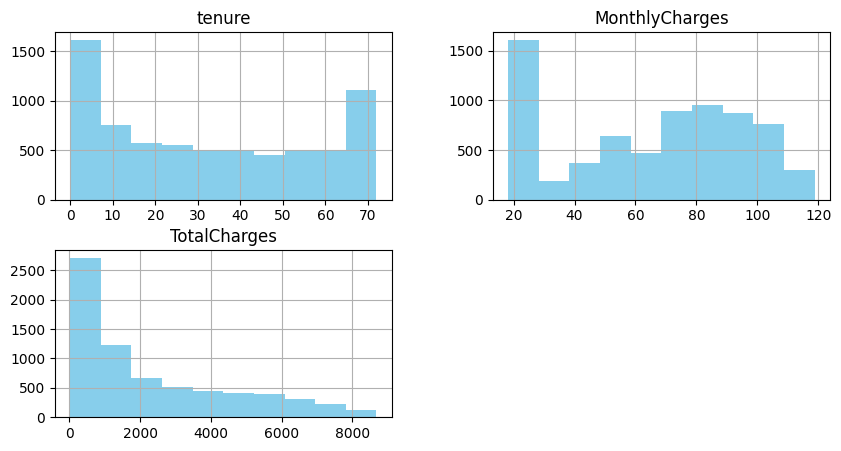

In [38]:
df.hist(bins=10, figsize=(10,5), facecolor = 'skyblue')

Com essas distribuições vemos que tem mais pessoas com pouco tempo de adesão do serviço do que pessoas com mais tempo. Mas que também, os menores valores de taxas são concentrados em mais pessoas.  
Além disso, as cobranças totais estão distrbuidas em um cauda assimétrica, onde poucas pessoas tem custos elevados mas são suficientes para enviesar o valor de média e tornar a mediana mais segura para substituição. Porém, isso será valido com mais certeza em sequencia.

In [39]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


## 1.1) Boxplot  

In [40]:
# Função apra determinar o grafico e limites de quartis
def quartis(coluna):
    '''Calcular os limites dos quartis'''

    # Gráfico
    df[coluna].plot(kind = 'box', vert = False, figsize=(15,3))
    plt.show

    # Definir os limites
    Q1 = df[coluna].quantile(q=0.25) # Quartil 1
    Q3 = df[coluna].quantile(q=0.75) # Quartil 3
    DQ = Q3 - Q1 # Dif interquartil

    LI = round(Q1 - 1.5*DQ, 2) #Limite inferior
    LS = round(Q3 + 1.5*DQ, 2) #Limite superior

    print(f'O valor do Limite superior é {LS} enquanto o valor do Limite Inferior é {LI}')
    print(f'Existem {len(df[df[coluna]> LS])} registros acima de {LS}')

    return LS

### A) Tenure

Para entender os limites de quartis, é aplicado a função de calculo dos limites.

O valor do Limite superior é 124.0 enquanto o valor do Limite Inferior é -60.0
Existem 0 registros acima de 124.0


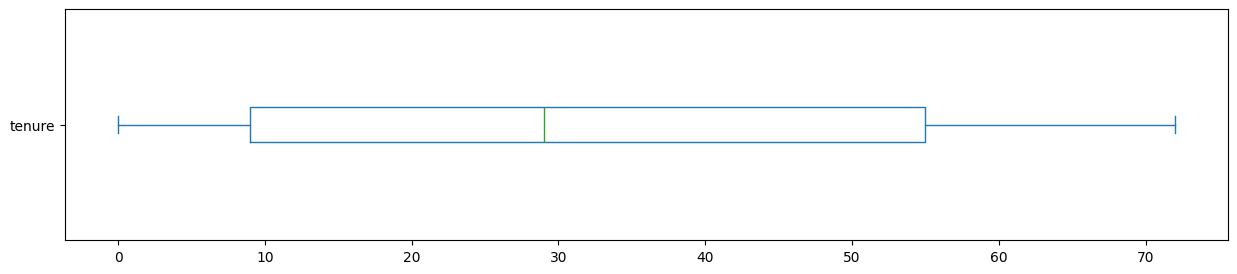

In [41]:
# Tenure
LS_tenure = quartis('tenure')

### B) MonthlyCharges

O valor do Limite superior é 171.38 enquanto o valor do Limite Inferior é -46.02
Existem 0 registros acima de 171.38


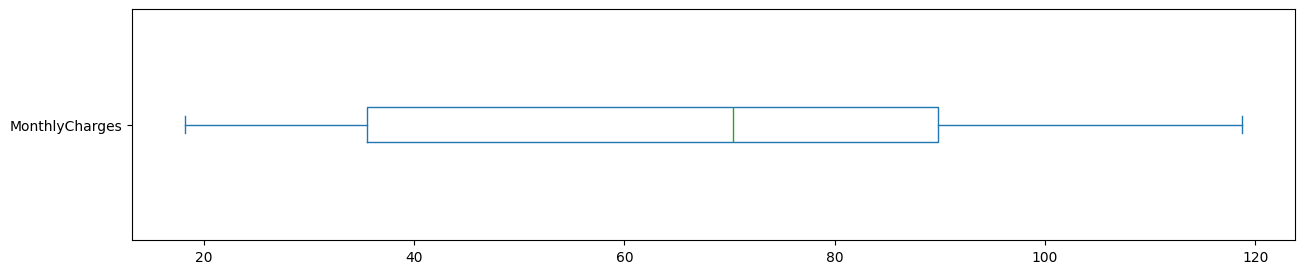

In [42]:
# MonthlyCharges
LS_monthly_charges = quartis('MonthlyCharges')

### C) TotalCharges

O valor do Limite superior é 8884.67 enquanto o valor do Limite Inferior é -4688.48
Existem 0 registros acima de 8884.67


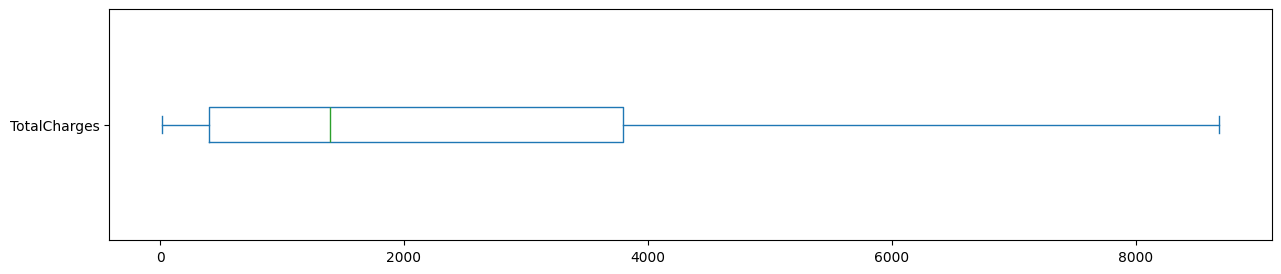

In [43]:
# TotalCharges
LS_tt_charges = quartis('TotalCharges')

Nenhuma das variáveis numéricas apresentam valores acima do Limite Superior do Quartil, o que pode indicar que não há outliers.  
Agora, o foco será tratar os dados ausentes na variavel TotalCharges.

In [44]:
# Entendendo quais são os registros com essa condição
df_temp = df[df['TotalCharges'].isna()]
df_temp

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Os registros sem valores de ChargesTotal apresentam tenure igual a 0 e sem cancelamentos, ou seja, são os novos clientes que não completaram o primeiro mês.  
Dado esse motivo, é coerente a eliminação desses registros e todos com ternune igual à 0,visto que são usuários que não tiveram tempo hábil pra optar pelo não cancelamento

In [45]:
# Aplicando a condição
df = df[df['tenure'] > 0] 

# Verificando se ainda tem nulos
print(df['TotalCharges'].isna().sum())

0


## 1.2) Análise de Correlação e Multicolenearidade

In [46]:
# Transformando a variável alvo em 0 e 1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn'].unique()

array([0, 1])

In [47]:
# Transformando quantitativas em binárias
df_corr = pd.get_dummies(
    df, columns=[
        'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 
        'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
        'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
        'Contract', 'PaperlessBilling', 'PaymentMethod'
    ], drop_first= True
)
df_corr.rename(
    columns={'Churn_1': 'Churn'}, inplace= True
)
df_corr.columns

Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male',
       'SeniorCitizen_1', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')

<function matplotlib.pyplot.show(close=None, block=None)>

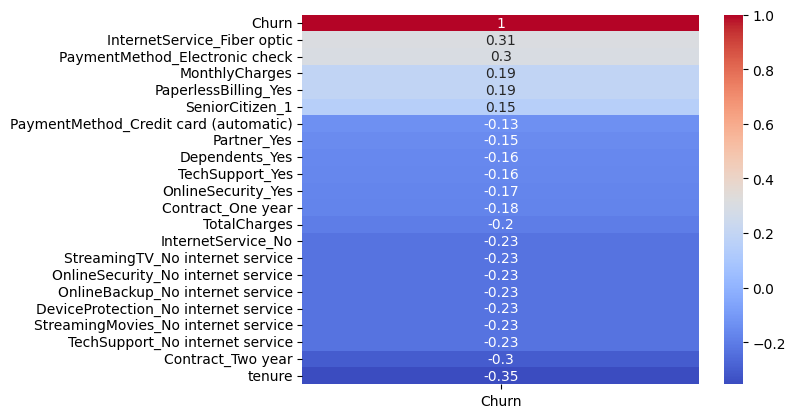

In [48]:
# Calcular os valores de correlação somente para variáveis com relação com Churn
churn_corr = df_corr.corr()[['Churn']].sort_values(by= 'Churn', ascending= False)
# Pegar somente as de valor > 0.1 para melhor visualização, dado que menor que isso não é relevante para esse análise
churn_corr = churn_corr[abs(churn_corr['Churn']) > 0.1]
sns.heatmap(
    churn_corr, annot= True, cmap= 'coolwarm'
)
plt.show

Conforme o gráfico de correlação, conclui-se o seguinte:  
* O tempo de adesão ao serviço é a variável com maior correlação (Quanto maior o tempo, menor a chance de Churn),  
* Seguido por internet quando do tipo fibra ótica (O uso dessa implica no aumento de Churn),  
* Em sequencia, há o contrato determinando em dois anos (o tempo do contrato reduz o risco de Churn)